# SPARCS Pareto analysis (sparcs_pareto.ipynb)

**Purpose:** Perform Pareto-style analysis on SPARCS hospitalization data to identify top contributing diagnoses, providers, or ZIP3 areas.

**Input:** SPARCS CSVs under data_csv/SPARCS/

**Dependencies:** pandas, numpy, matplotlib

**How to run:** Ensure SPARCS files are available and run the notebook; some plotting cells may be interactive and expect a display backend.


In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import re

In [ ]:
# ------------------------------------
# File Path
# ------------------------------------
sparcs_path = "data_csv/SPARCS/"

# ------------------------------------
# Select ONLY specific files for 5 year period
# ------------------------------------
#target_years = [str(year) for year in range(2010, 2016)]
#target_years = [str(year) for year in range(2016, 2021)]
target_years = [str(year) for year in range(2021, 2025)]

sparcs_files = []

for file in glob.glob(os.path.join(sparcs_path, "*.csv")):

    filename = os.path.basename(file)

    # Check if filename contains any target year
    if any(f"__{year}_" in filename for year in target_years):
        sparcs_files.append(file)

asthma_list = []
pareto_list = []


In [3]:
# ------------------------------------
# Loop through yearly files
# ------------------------------------
for file in sparcs_files:

    filename = os.path.basename(file)

    # Extract year after "__"
    match = re.search(r'__(\d{4})_', filename)

    if match:
        year = int(match.group(1))
    else:
        raise ValueError(f"Could not extract year from filename: {filename}")

    print(f"Processing {year}...")

    chunk_iter = pd.read_csv(
        file,
        chunksize=500000,
        low_memory=False
    )

    for chunk in chunk_iter:

        # --------------------------------
        # Standardize ZIP column
        # --------------------------------
        if "Zip Code - 3 digits" in chunk.columns:
            chunk = chunk.rename(columns={"Zip Code - 3 digits": "zip3"})

        elif "Zip Code" in chunk.columns:
            chunk = chunk.rename(columns={"Zip Code": "zip3"})

        else:
            raise KeyError("No ZIP column found.")

        # Clean ZIP3
        chunk["zip3"] = (
            chunk["zip3"]
            .astype(str)
            .str.extract(r'(\d{3})')
        )

        chunk = chunk.dropna(subset=["zip3"])

        # --------------------------------
        # Ensure Age Group exists
        # --------------------------------
        if "Age Group" not in chunk.columns:
            raise KeyError("Age Group column not found.")

        # --------------------------------
        # Diagnosis Description Column
        # --------------------------------
        if "CCSR Diagnosis Description" in chunk.columns:
            diag_col = "CCSR Diagnosis Description"

        elif "CCS Diagnosis Description" in chunk.columns:
            diag_col = "CCS Diagnosis Description"

        else:
            raise KeyError("No diagnosis description column found.")

        # --------------------------------
        # Respiratory Filtering
        # --------------------------------
        respiratory_keywords = [
            "Asthma",
            "Respiratory",
            "Bronchitis",
            "COPD",
            "Pneumonia",
            "Airway",
            "Wheezing"
        ]

        respiratory_pattern = "|".join(respiratory_keywords)

        respiratory = chunk[
            chunk[diag_col]
            .astype(str)
            .str.contains(respiratory_pattern,
                          case=False,
                          na=False)
        ].copy()

        if respiratory.empty:
            continue

        # --------------------------------
        # Normalize diagnosis column name
        # --------------------------------
        if diag_col != "CCSR Diagnosis Description":
            respiratory = respiratory.rename(
                columns={diag_col: "CCSR Diagnosis Description"}
            )

        # --------------------------------
        # Create Aggregated Hospitalization Category
        # --------------------------------
        def categorize_reason(x):

            x = str(x).lower()

            if "asthma" in x:
                return "Asthma Exacerbation"

            elif ("pneumonia" in x) or ("bronchitis" in x):
                return "Respiratory Infection"

            elif "copd" in x:
                return "COPD-related"

            elif "respiratory failure" in x:
                return "Respiratory Failure"

            elif ("airway" in x) or ("wheezing" in x):
                return "Airway Complications"

            else:
                return "Other Respiratory Disorders"

        respiratory["Hospitalization_Reason_Group"] = (
            respiratory["CCSR Diagnosis Description"]
            .apply(categorize_reason)
        )

        # --------------------------------
        # Filter ONLY asthma-related hospitalizations
        # --------------------------------
        asthma = respiratory[
            respiratory["Hospitalization_Reason_Group"]
            .isin([
                "Asthma Exacerbation",
                "Respiratory Infection",
                "COPD-related",
                "Respiratory Failure",
                "Airway Complications",
                "Other Respiratory Disorders"
            ])
        ].copy()

        if asthma.empty:
            continue

        # --------------------------------
        # Clean Currency Fields
        # --------------------------------
        for currency_col in ["Total Charges", "Total Costs"]:

            if currency_col in asthma.columns:

                asthma[currency_col] = (
                    asthma[currency_col]
                    .astype(str)
                    .str.replace(r'[\$,\s]', '',
                                 regex=True)
                    .replace('', np.nan)
                    .replace('nan', np.nan)
                    .pipe(pd.to_numeric,
                          errors='coerce')
                )

        # --------------------------------
        # Mortality Mapping
        # --------------------------------
        mortality_map = {
            "Minor": 1,
            "Moderate": 2,
            "Major": 3,
            "Extreme": 4
        }

        if "APR Risk of Mortality" in asthma.columns:

            asthma["APR Risk of Mortality"] = (
                asthma["APR Risk of Mortality"]
                .astype(str)
                .str.strip()
                .map(mortality_map)
            )

        # --------------------------------
        # Numeric Cleanup
        # --------------------------------
        numeric_cols = [
            "Length of Stay",
            "APR Severity of Illness Code",
            "APR Risk of Mortality"
        ]

        for col in numeric_cols:

            if col in asthma.columns:
                asthma[col] = pd.to_numeric(
                    asthma[col],
                    errors="coerce"
                )

        # --------------------------------
        # Derived Indicators
        # --------------------------------
        asthma["ED_Visit"] = np.where(
            asthma["Emergency Department Indicator"]
            .astype(str)
            .str.upper() == "Y",
            1,
            0
        )

        # Medicaid Flag
        if "Payment Typology 1" in asthma.columns:

            asthma["Medicaid"] = np.where(
                asthma["Payment Typology 1"]
                .str.contains("Medicaid",
                              case=False,
                              na=False),
                1,
                0
            )

        else:
            asthma["Medicaid"] = 0

        # --------------------------------
        # Main Grouped Dataset
        # --------------------------------
        grouped = asthma.groupby(
            ["zip3",
             "Age Group",
             "Hospitalization_Reason_Group"]
        ).agg(
            Asthma_Cases=("zip3", "size"),
            ED_Visits=("ED_Visit", "sum"),
            Avg_Length_of_Stay=("Length of Stay", "mean"),
            Avg_Severity=("APR Severity of Illness Code", "mean"),
            Avg_Mortality_Risk=("APR Risk of Mortality", "mean"),
            Total_Charges=("Total Charges", "sum"),
            Total_Costs=("Total Costs", "sum"),
            Avg_Costs=("Total Costs", "mean"),
            Medicaid_Cases=("Medicaid", "sum")
        ).reset_index()

        grouped["Year"] = year

        asthma_list.append(grouped)

        # --------------------------------
        # Pareto Aggregation Dataset
        # --------------------------------
        pareto_chunk = asthma.groupby(
            "Hospitalization_Reason_Group"
        ).size().reset_index(name="Count")

        pareto_chunk["Year"] = year

        pareto_list.append(pareto_chunk)

# ------------------------------------
# Combine Main Dataset
# ------------------------------------
if not asthma_list:

    print("No asthma cases found across all files.")

else:

    sparcs_combined = pd.concat(
        asthma_list,
        ignore_index=True
    )

    sparcs_final = sparcs_combined.groupby(
        [
            "Year",
            "zip3",
            "Age Group",
            "Hospitalization_Reason_Group"
        ]
    ).agg({
        "Asthma_Cases": "sum",
        "ED_Visits": "sum",
        "Avg_Length_of_Stay": "mean",
        "Avg_Severity": "mean",
        "Avg_Mortality_Risk": "mean",
        "Total_Charges": "sum",
        "Total_Costs": "sum",
        "Avg_Costs": "mean",
        "Medicaid_Cases": "sum"
    }).reset_index()

    # --------------------------------
    # Rates
    # --------------------------------
    sparcs_final["ED_Rate"] = (
        sparcs_final["ED_Visits"]
        / sparcs_final["Asthma_Cases"]
    )

    sparcs_final["Medicaid_Rate"] = (
        sparcs_final["Medicaid_Cases"]
        / sparcs_final["Asthma_Cases"]
    )

    print(sparcs_final.head())


Processing 2021...


KeyboardInterrupt: 

In [12]:
# ------------------------------------
# Combine Main Dataset
# ------------------------------------
if not asthma_list:

    print("No asthma cases found across all files.")

else:

    sparcs_combined = pd.concat(
        asthma_list,
        ignore_index=True
    )

    sparcs_final = sparcs_combined.groupby(
        [
            "Year",
            "zip3",
            "Age Group",
            "Hospitalization_Reason_Group"
        ]
    ).agg({
        "Asthma_Cases": "sum",
        "ED_Visits": "sum",
        "Avg_Length_of_Stay": "mean",
        "Avg_Severity": "mean",
        "Avg_Mortality_Risk": "mean",
        "Total_Charges": "sum",
        "Total_Costs": "sum",
        "Avg_Costs": "mean",
        "Medicaid_Cases": "sum"
    }).reset_index()

    # --------------------------------
    # Rates
    # --------------------------------
    sparcs_final["ED_Rate"] = (
        sparcs_final["ED_Visits"]
        / sparcs_final["Asthma_Cases"]
    )

    sparcs_final["Medicaid_Rate"] = (
        sparcs_final["Medicaid_Cases"]
        / sparcs_final["Asthma_Cases"]
    )

    # --------------------------------
    # Preview
    # --------------------------------
    print(sparcs_final.head())

    # --------------------------------
    # SAVE AGGREGATED FILE TO CSV
    # --------------------------------
    output_path = "data_csv/sparcs_asthma_aggregated_2021_2024.csv"

    # Create output directory if it does not exist
    os.makedirs("data_csv", exist_ok=True)

    # Save CSV
    sparcs_final.to_csv(
        output_path,
        index=False
    )

    print(f"\nAggregated file saved successfully:")
    print(output_path)

   Year zip3 Age Group Hospitalization_Reason_Group  Asthma_Cases  ED_Visits  \
0  2021  100   0 to 17          Asthma Exacerbation           437        400   
1  2021  100   0 to 17  Other Respiratory Disorders           144        102   
2  2021  100   0 to 17          Respiratory Failure            64         58   
3  2021  100   0 to 17        Respiratory Infection           392        353   
4  2021  100  18 to 29          Asthma Exacerbation            94         91   

   Avg_Length_of_Stay  Avg_Severity  Avg_Mortality_Risk  Total_Charges  \
0            2.090479      1.627204            1.301908    16023124.76   
1            3.254368      2.109240            1.499149    14788111.73   
2            4.211429      2.278769            1.383590     8834839.36   
3            2.600572      2.175512            1.536248    19409752.57   
4            1.950947      2.131692            2.016225     3495861.63   

   Total_Costs     Avg_Costs  Medicaid_Cases   ED_Rate  Medicaid_Rate  
0 

In [13]:
# ------------------------------------
# File Paths
# ------------------------------------
file_1 = "data_csv/sparcs_asthma_aggregated_2010_2015.csv"
file_2 = "data_csv/sparcs_asthma_aggregated_2016_2020.csv"
file_3 = "data_csv/sparcs_asthma_aggregated_2021_2024.csv"

# ------------------------------------
# Read CSV Files
# ------------------------------------
df1 = pd.read_csv(file_1)
df2 = pd.read_csv(file_2)
df3 = pd.read_csv(file_3)

# ------------------------------------
# Combine All Files
# ------------------------------------
combined_df = pd.concat(
    [df1, df2, df3],
    ignore_index=True
)

# ------------------------------------
# Optional: Remove Duplicate Rows
# ------------------------------------
combined_df = combined_df.drop_duplicates()

# ------------------------------------
# Optional: Sort Data
# ------------------------------------
combined_df = combined_df.sort_values(
    by=["Year", "zip3", "Age Group"]
)

# ------------------------------------
# Reset Index
# ------------------------------------
combined_df = combined_df.reset_index(drop=True)

# ------------------------------------
# Create Output Directory
# ------------------------------------
os.makedirs("data_csv", exist_ok=True)

# ------------------------------------
# Save Final Combined CSV
# ------------------------------------
output_file = "data_csv/sparcs_asthma_aggregated_2010_2024.csv"

combined_df.to_csv(
    output_file,
    index=False
)

# ------------------------------------
# Preview
# ------------------------------------
print(combined_df.head())

print("\nCombined file saved successfully:")
print(output_file)

# ------------------------------------
# Shape Check
# ------------------------------------
print("\nFinal Dataset Shape:")
print(combined_df.shape)

   Year  zip3 Age Group Hospitalization_Reason_Group  Asthma_Cases  ED_Visits  \
0  2010   100   0 to 17          Asthma Exacerbation           907        837   
1  2010   100   0 to 17                 COPD-related             9          4   
2  2010   100   0 to 17        Respiratory Infection           899        795   
3  2010   100  18 to 29          Asthma Exacerbation           233        208   
4  2010   100  18 to 29                 COPD-related             7          7   

   Avg_Length_of_Stay  Avg_Severity  Avg_Mortality_Risk  Total_Charges  \
0            2.075161      1.288378            1.037870    10984565.92   
1            5.166667      2.333333            1.083333      290967.51   
2            3.302435      1.870554            1.045606    15378510.39   
3            2.496091      1.485723            1.121176     3667256.97   
4            4.857143      2.428571            1.714286      273020.04   

   Total_Costs     Avg_Costs  Medicaid_Cases   ED_Rate  Medicaid_Rat

In [14]:

# ------------------------------------
# PARETO DATASET
# ------------------------------------
pareto_df = pd.concat(
    pareto_list,
    ignore_index=True
)

pareto_final = pareto_df.groupby(
    "Hospitalization_Reason_Group"
)["Count"].sum().reset_index()

# ------------------------------------
# Sort Descending
# ------------------------------------
pareto_final = pareto_final.sort_values(
    by="Count",
    ascending=False
)

# ------------------------------------
# Percentage Calculation
# ------------------------------------
pareto_final["Percentage"] = (
    pareto_final["Count"]
    / pareto_final["Count"].sum()
) * 100

# ------------------------------------
# Cumulative Percentage
# ------------------------------------
pareto_final["Cumulative_Percentage"] = (
    pareto_final["Percentage"]
    .cumsum()
)

print(pareto_final)


  Hospitalization_Reason_Group   Count  Percentage  Cumulative_Percentage
3        Respiratory Infection  144967   39.120004              39.120004
2          Respiratory Failure   85771   23.145694              62.265699
1  Other Respiratory Disorders   81767   22.065197              84.330896
0          Asthma Exacerbation   58065   15.669104             100.000000


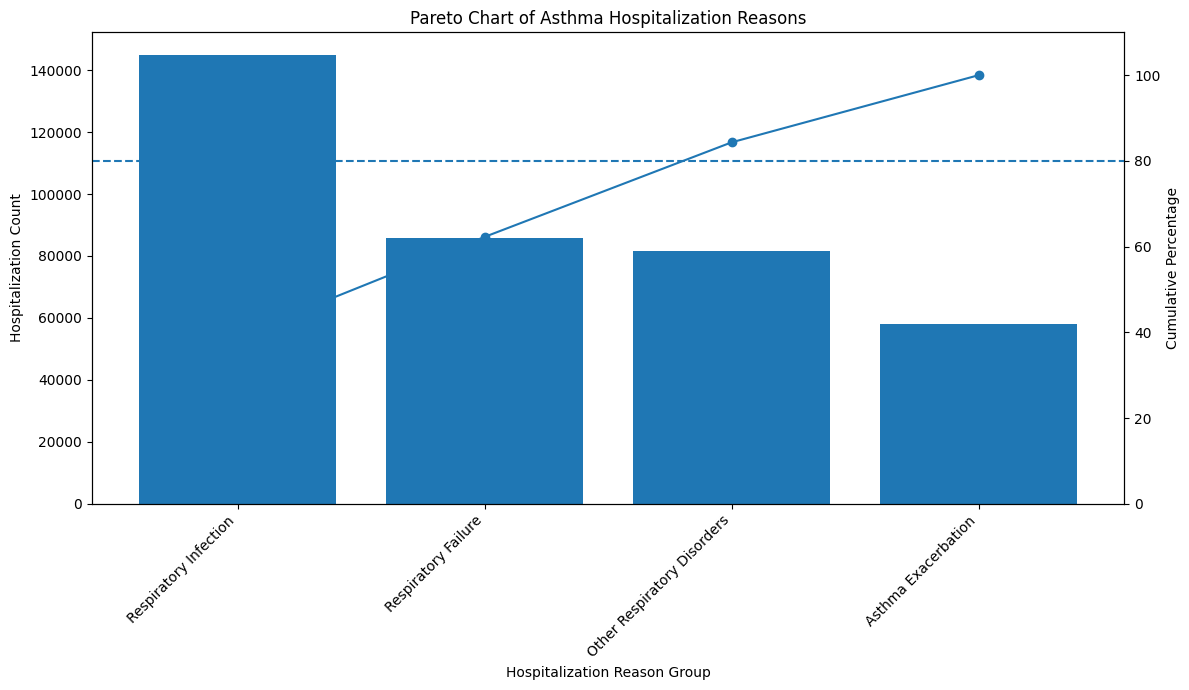

In [15]:

# ------------------------------------
# PARETO CHART
# ------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar chart
ax1.bar(
    pareto_final["Hospitalization_Reason_Group"],
    pareto_final["Count"]
)

ax1.set_xlabel("Hospitalization Reason Group")
ax1.set_ylabel("Hospitalization Count")

plt.xticks(rotation=45, ha='right')

# Secondary axis for cumulative %
ax2 = ax1.twinx()

ax2.plot(
    pareto_final["Hospitalization_Reason_Group"],
    pareto_final["Cumulative_Percentage"],
    marker='o'
)

ax2.set_ylabel("Cumulative Percentage")
ax2.set_ylim(0, 110)

# 80% reference line
ax2.axhline(80, linestyle='--')

# Title
plt.title(
    "Pareto Chart of Asthma Hospitalization Reasons"
)

plt.tight_layout()

plt.show()